# CMIP6 data analysis challenge for Saroma sea ice school 2026

From the previous three Notebooks, you have learned the basics of plotting figures and obtaining CMIP6 data from Pangeo. Now, let's try producing a few figures from scratch!

## Question: What could be a future scenario for marine productivity and sea-ice conditions in the Sea of Okhotsk? 

To answer this question, we will obtain CMIP6 data from Pangeo using `intake` and visualize the results using `cartopy` as demonstrated in the previous Notebooks. 

Specifically, we will use sea surface chlorophyll concentration (called `chlos` in CMIP6 data) and sea-ice concentration (`siconc`) as proxies for marine productivity and sea-ice conditions. Ideally, we should look at multiple models and ensembles, but due to both time constraint and the lack of some model output in Pangeo, let's look at the output of a specific model called `GFDL-ESM4`. We will get the output from two experiments called `historical` which spans 1850-2014 and `ssp585` (the worst-case scenario and NOT the business-as-usual scenario😉) which spans 2015-2100. For simplicity, we will get the output that has been provided as a 1-degree regular grid (`gr`) and only consider the first ensemble member `r1i1p1f1`.

### Step 1

Import the neccesary libraries and load the required CMIP6 data, i.e.,
- source_id = 'GFDL-ESM4'
- experiment_id = ['historical', 'ssp585']
- variable_id = ['chlos', 'siconc']
- grid_label = 'gr',
- member_id = 'r1i1p1f1'

In [6]:
import intake
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs

cat_url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"

col = intake.open_esm_datastore(cat_url)

cat = col.search(
    source_id=['GFDL-ESM4'],
    experiment_id=['historical','ssp585'],
    variable_id=["chlos","siconc"],
    grid_label='gr',
    member_id=['r1i1p1f1'])

dset_dict = cat.to_dataset_dict(zarr_kwargs={"consolidated": True, "decode_times": True, "use_cftime": True})

dataset_list = sorted(dset_dict.keys())
print(dataset_list)

# .squeeze() is used to drop dimension(s) of size 1
ds_chl_his = dset_dict[dataset_list[0]]["chlos"].squeeze() * 1e6
ds_chl_585 = dset_dict[dataset_list[2]]["chlos"].squeeze() * 1e6
ds_ice_his = dset_dict[dataset_list[1]]["siconc"].squeeze()
ds_ice_585 = dset_dict[dataset_list[3]]["siconc"].squeeze()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="4" value="4"></progress> 100.00% [4/4 00:00&lt;00:00]</div>

/Users/hakaseh/miniconda3/envs/cmip_env/lib/python3.12/site-packages/intake_esm/source.py:109: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(url, **xarray_open_kwargs)
/Users/hakaseh/miniconda3/envs/cmip_env/lib/python3.12/site-packages/intake_esm/source.py:109: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(url, **xarray_open_kwargs)
/Users/hakaseh/miniconda3/envs/cmip_env/lib/python3.12/site-packages/intake_esm/source.py:109: FutureWarning: Usage 

['CMIP.NOAA-GFDL.GFDL-ESM4.historical.Omon.gr', 'CMIP.NOAA-GFDL.GFDL-ESM4.historical.SImon.gr', 'ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585.Omon.gr', 'ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585.SImon.gr']


### Step 2

Plot the spatial distribution of sea surface chlorophyll concentration averaged over the last 30 years of the historical experiment (1985-2014). Similarly, compute the sea ice concentration averaged over 1985-2014 and add to the chlorophyll map as a contour line for the value of 15%, which is a proxy for sea-ice cover (15% of grid cell surface is covered by sea ice). Make the map to display only the Sea of Okhotsk (139-163 deg-E and 41-62 deg-N).

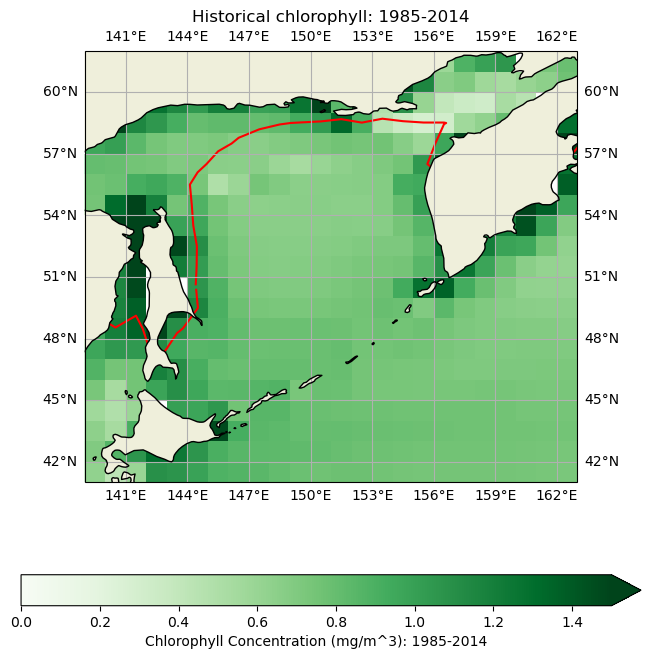

In [7]:
lon0 = 139
lon1 = 163
lat0 = 41
lat1 = 62

# 1. Define the projection you want for the DISPLAY (Polar)
proj = ccrs.PlateCarree()

# 2. Setup the plot with subplots
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})

# 3. Plot using the 'transform' keyword to tell Xarray your data is Lat/Lon
ds_chl_his.sel(time=slice("19850101","20141231")).mean(dim='time').plot(vmin=0,vmax=1.5, cmap="Greens", ax=ax, transform=ccrs.PlateCarree(),
                cbar_kwargs={'orientation': 'horizontal','label': 'Chlorophyll Concentration (mg/m^3): 1985-2014'})
ds_ice_his.sel(time=slice("19850101","20141231")).mean(dim='time').plot.contour(colors='r', levels=[15], ax=ax, transform=ccrs.PlateCarree())

# 4. Add map features
ax.coastlines(zorder=3)
ax.add_feature(cfeature.LAND,zorder=2)
ax.gridlines(draw_labels=True)
ax.set_title("Historical chlorophyll: 1985-2014")

# 5. Set the extent to zoom in on the pole
ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())

### Step 3

Do the same as Step 2 but using the projection output (`ssp585`).

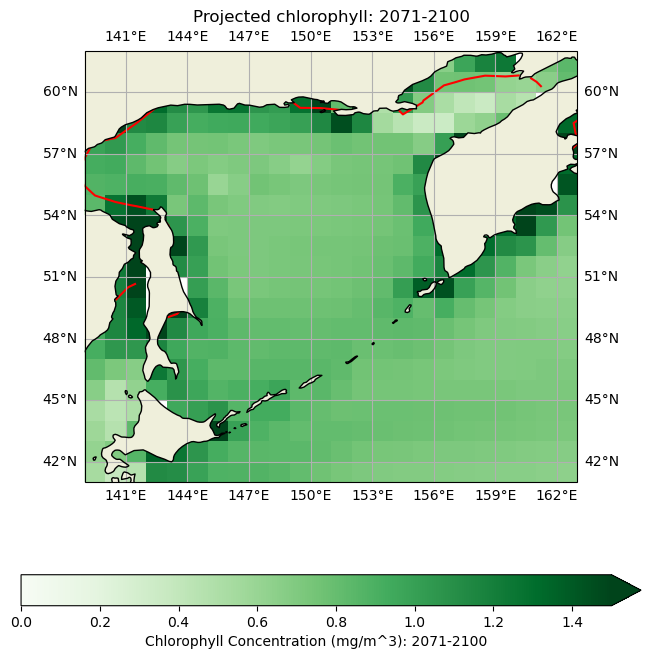

In [8]:
# 1. Define the projection you want for the DISPLAY (Polar)
proj = ccrs.PlateCarree()

# 2. Setup the plot with subplots
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})

# 3. Plot using the 'transform' keyword to tell Xarray your data is Lat/Lon
ds_chl_585.sel(time=slice("20710101","21001231")).mean(dim='time').plot(vmin=0,vmax=1.5, cmap="Greens", ax=ax, transform=ccrs.PlateCarree(),
    cbar_kwargs={'orientation': 'horizontal','label': 'Chlorophyll Concentration (mg/m^3): 2071-2100'})
ds_ice_585.sel(time=slice("20710101","21001231")).mean(dim='time').plot.contour(colors='r', levels=[15], ax=ax, transform=ccrs.PlateCarree())

# 4. Add map features
ax.coastlines(zorder=3)
ax.add_feature(cfeature.LAND,zorder=2)
ax.gridlines(draw_labels=True)
ax.set_title("Projected chlorophyll: 2071-2100")

# 5. Set the extent to zoom in on the pole
ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())

### Step 4

By comparing the two figures above, you will notice a remarkable reduction in sea-ice cover! However, it is difficult to tell the chlorophyll concentration difference. So let's now plot the chlorophyll concentration difference between the two periods (2071-2100 minus 1985-2014).

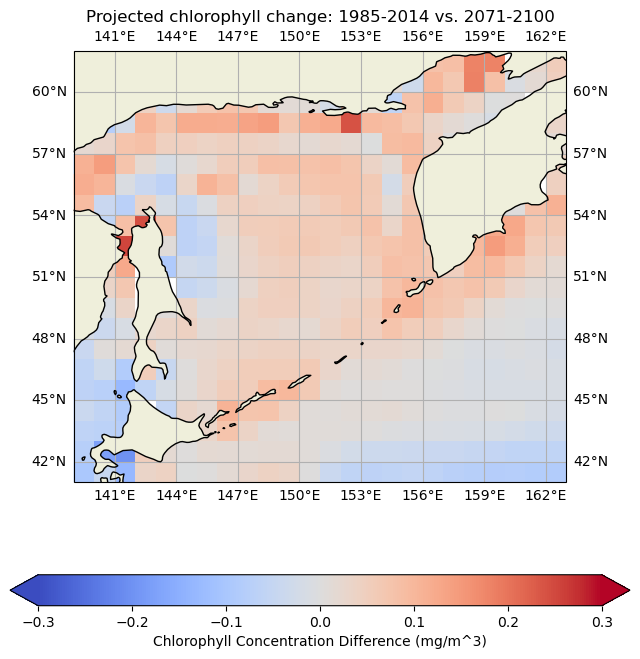

In [9]:
# 1. Define the projection you want for the DISPLAY (Polar)
proj = ccrs.PlateCarree()

# 2. Setup the plot with subplots
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})

# 3. Plot using the 'transform' keyword to tell Xarray your data is Lat/Lon
# (Assuming 'ds' is your DataArray)
ds_chl_dif = ds_chl_585.sel(time=slice("20710101","21001231")).mean(dim='time') - ds_chl_his.sel(time=slice("19850101","20141231")).mean(dim='time')
ds_chl_dif.plot(vmin=-0.3, vmax=0.3, cmap="coolwarm", ax=ax, transform=ccrs.PlateCarree(),
               cbar_kwargs={'orientation': 'horizontal','label': 'Chlorophyll Concentration Difference (mg/m^3)'})

# 4. Add map features
ax.coastlines(zorder=3)
ax.add_feature(cfeature.LAND,zorder=2)
ax.gridlines(draw_labels=True)
ax.set_title("Projected chlorophyll change: 1985-2014 vs. 2071-2100")
# 5. Set the extent to zoom in on the pole
ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())

### Step 5

There are positives and negatives in the chlorophyll anomalies but it appears that the marine producitivity has increased in areas that were covered by sea ice during the historical period. Could there be a correlation between chlorophyll and sea-ice concentration? Let's check by calculating the annual-mean chlorophyll averaged over the northern part of the Sea of Okhotsk (141-159 deg-E and 57-60 deg-N) in the projection output (`ssp585`). Do the same for sea-ice concentration. And create a scatter plot between these varaibles and calculate the correlation coefficient.

The Pearson correlation between chlorophyll and sea-ice concentration is -0.51 [-0.65--0.33] at the 95% level


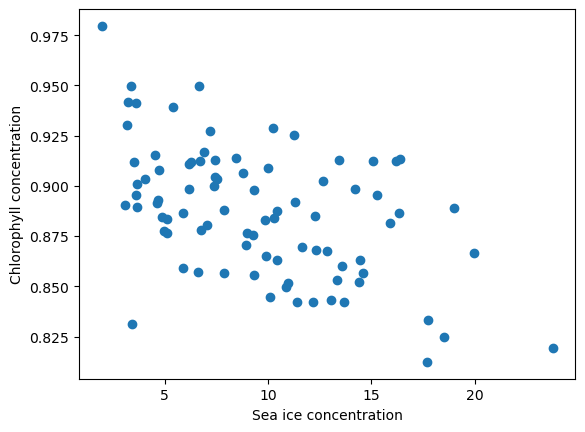

In [10]:
# Define the lon/lat range for the northern part of the Sea of Okhotsk
lon00 = 141
lon11 = 159
lat00 = 57
lat11 = 60

from scipy.stats import pearsonr

def correlation(obs, model, level=0.95):
    '''
    this function is for the Pearson correlation coefficient, i.e. assuming linear correlation
    another usual non-parametric test is the Spearman correlation (see scipy.stats.spearmanr)
    '''
#    nans = np.isnan(obs)+np.isnan(model)
    r = pearsonr(obs,model)
    r_coeff = r[0]
    ci = r.confidence_interval(confidence_level=level)
    return r_coeff, ci

# Calculating the area-averaged annual-mean time series
ts_chl = ds_chl_585.sel(lon=slice(lon00,lon11),lat=slice(lat00,lat11)).mean(dim=('lat','lon')).groupby('time.year').mean()
ts_ice = ds_ice_585.sel(lon=slice(lon00,lon11),lat=slice(lat00,lat11)).mean(dim=('lat','lon')).groupby('time.year').mean()

# Scatter plot
plt.scatter(ts_ice,ts_chl)
plt.xlabel('Sea ice concentration')
plt.ylabel('Chlorophyll concentration')

# Correlation calculation
level = 0.95
r, ci = correlation(ts_ice, ts_chl, level)
print('The Pearson correlation between chlorophyll and sea-ice concentration is '+str(round(r,2))+' ['+str(round(ci.low,2))+'-'+str(round(ci.high,2))+'] at the '+str(int(level*100.0))+'% level')

### The end: So what was the correlation coefficient?